# Manual Depth-Based Obstacle Detection
This notebook demonstrates depth-based obstacle detection using the DPT (Dense Prediction Transformer) model.

## Features:
- Load depth estimation model from local directory
- Process images or videos
- Detect obstacles in a defined danger zone
- Visualize depth maps and danger zones
- Calculate obstacle distances

## 1. Import Libraries

In [6]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import DPTImageProcessor, DPTForDepthEstimation
import os
from pathlib import Path

# For better visualization
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.5.1+cu121
CUDA available: True


## 2. Configuration

In [11]:
# ========== CONFIGURATION ==========
# Model settings
MODEL_PATH = "./local_models"  # Local model path

# Detection parameters
STOP_DISTANCE_M = 15.0         # Stop if obstacle closer than 15 meters
LOOK_AHEAD_Y_FRAC = 0.70       # Check top 70% of image (ignore bottom 30%)
PIXEL_COUNT_THRESHOLD = 50     # Minimum pixels to trigger obstacle detection
DANGER_ZONE_COLOR = (0, 0, 255) # Red color for danger zone overlay

# Input/Output paths
INPUT_IMAGE_PATH = "original.jpg"     # Single image
INPUT_VIDEO_PATH = "test_video.mp4"     # Video file
OUTPUT_DIR = "output"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration set!")
print(f"Model path: {MODEL_PATH}")
print(f"Stop distance: {STOP_DISTANCE_M}m")
print(f"Output directory: {OUTPUT_DIR}")

Configuration set!
Model path: ./local_models
Stop distance: 15.0m
Output directory: output


## 3. Load Depth Estimation Model

In [12]:
# Check if model exists locally
if not os.path.exists(MODEL_PATH):
    print(f"⚠️ Model not found at {MODEL_PATH}")
    print("Please ensure the model is downloaded to the local_models directory.")
    print("You can download it using: transformers-cli download Intel/dpt-hybrid-midas")
else:
    print(f"✓ Model directory found at {MODEL_PATH}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and processor
print("Loading depth estimation model...")
try:
    processor = DPTImageProcessor.from_pretrained(MODEL_PATH)
    model = DPTForDepthEstimation.from_pretrained(
        MODEL_PATH,
        low_cpu_mem_usage=True
    ).to(device)
    model.eval()
    print("✓ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise

✓ Model directory found at ./local_models
Using device: cuda
Loading depth estimation model...
✓ Model loaded successfully!


## 4. Helper Functions

In [13]:
def estimate_depth(img_bgr, model, processor, device):
    """
    Estimate depth map for the given image.
    
    Args:
        img_bgr: Input image in BGR format (OpenCV)
        model: DPT model
        processor: DPT processor
        device: torch device
    
    Returns:
        depth_map: Depth map in meters (numpy array)
    """
    h, w = img_bgr.shape[:2]
    
    # Convert BGR to RGB for PIL
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    
    # Prepare inputs
    inputs = processor(images=img_pil, return_tensors="pt").to(device)
    
    # Predict depth
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth
    
    # Interpolate to original size
    depth_map = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=(h, w),
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu().numpy()
    
    return depth_map


def create_simple_danger_zone(h, w, look_ahead_frac=0.70):
    """
    Create a simple rectangular danger zone in the center of the image.
    This is used when lane detection is not available.
    
    Args:
        h: Image height
        w: Image width
        look_ahead_frac: Fraction of image height to check (from top)
    
    Returns:
        mask: Binary mask of danger zone
    """
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Define danger zone boundaries
    y_start = 0
    y_end = int(h * look_ahead_frac)
    x_start = int(w * 0.3)  # Center 40% of width
    x_end = int(w * 0.7)
    
    # Fill danger zone
    mask[y_start:y_end, x_start:x_end] = 255
    
    return mask


def check_obstacle(depth_map, danger_zone_mask, stop_distance_m, pixel_threshold):
    """
    Check if there's an obstacle in the danger zone.
    
    Args:
        depth_map: Depth map in meters
        danger_zone_mask: Binary mask of danger zone
        stop_distance_m: Distance threshold in meters
        pixel_threshold: Minimum number of pixels to trigger detection
    
    Returns:
        obstacle_found: Boolean
        min_distance: Minimum distance in danger zone
        num_pixels_close: Number of pixels closer than threshold
    """
    if np.sum(danger_zone_mask) == 0:
        return False, float('inf'), 0
    
    # Get depths in danger zone
    depths_in_zone = depth_map[danger_zone_mask > 0]
    
    # Count pixels closer than threshold
    pixels_too_close = np.sum(depths_in_zone < stop_distance_m)
    min_distance = np.min(depths_in_zone) if len(depths_in_zone) > 0 else float('inf')
    
    # Determine if obstacle detected
    obstacle_found = pixels_too_close > pixel_threshold
    
    return obstacle_found, min_distance, pixels_too_close


def visualize_results(img_bgr, depth_map, danger_zone_mask, obstacle_found, 
                     min_distance, num_pixels_close):
    """
    Create a comprehensive visualization of the detection results.
    
    Returns:
        fig: matplotlib figure
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Original image with danger zone overlay
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[danger_zone_mask > 0] = [255, 0, 0]  # Red overlay
    blended = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
    
    axes[0, 0].imshow(blended)
    axes[0, 0].set_title('Original Image with Danger Zone', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Add status text
    status_text = "OBSTACLE DETECTED!" if obstacle_found else "Clear"
    status_color = 'red' if obstacle_found else 'green'
    axes[0, 0].text(10, 30, status_text, color=status_color, 
                   fontsize=16, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Depth map (colorized)
    depth_normalized = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())
    depth_colored = plt.cm.viridis(depth_normalized)
    axes[0, 1].imshow(depth_colored)
    axes[0, 1].set_title('Depth Map (Viridis)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Depth map with distance scale
    im = axes[1, 0].imshow(depth_map, cmap='plasma', vmin=0, vmax=50)
    axes[1, 0].set_title('Depth Map (Meters)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], label='Distance (m)')
    
    # Statistics
    axes[1, 1].axis('off')
    stats_text = f"""
    DETECTION STATISTICS
    ═══════════════════════════════
    
    Obstacle Detected:  {obstacle_found}
    
    Minimum Distance:   {min_distance:.2f} m
    
    Pixels Too Close:   {num_pixels_close}
    
    Stop Threshold:     {STOP_DISTANCE_M} m
    
    Pixel Threshold:    {PIXEL_COUNT_THRESHOLD}
    
    Look-Ahead Zone:    {LOOK_AHEAD_Y_FRAC*100:.0f}% of image
    
    ═══════════════════════════════
    Status: {'🚨 STOP REQUIRED' if obstacle_found else '✓ SAFE TO PROCEED'}
    """
    
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

print("Helper functions defined!")

Helper functions defined!


## 5. Test on Single Image

Loading image from: original.jpg
✓ Image loaded: (640, 640, 3)
Estimating depth...
✓ Depth map generated: (640, 640)
  Depth range: -88.64m to 6953.71m
✓ Danger zone created: 114688 pixels

DETECTION RESULT:
  Obstacle Detected: True
  Minimum Distance: -51.38m
  Pixels Too Close: 65795



C:\Users\User\AppData\Local\Temp\ipykernel_23092\2431248235.py:163: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_23092\1246059852.py:48: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(output_path, dpi=150, bbox_inches='tight')


✓ Visualization saved to: output\detection_result.png


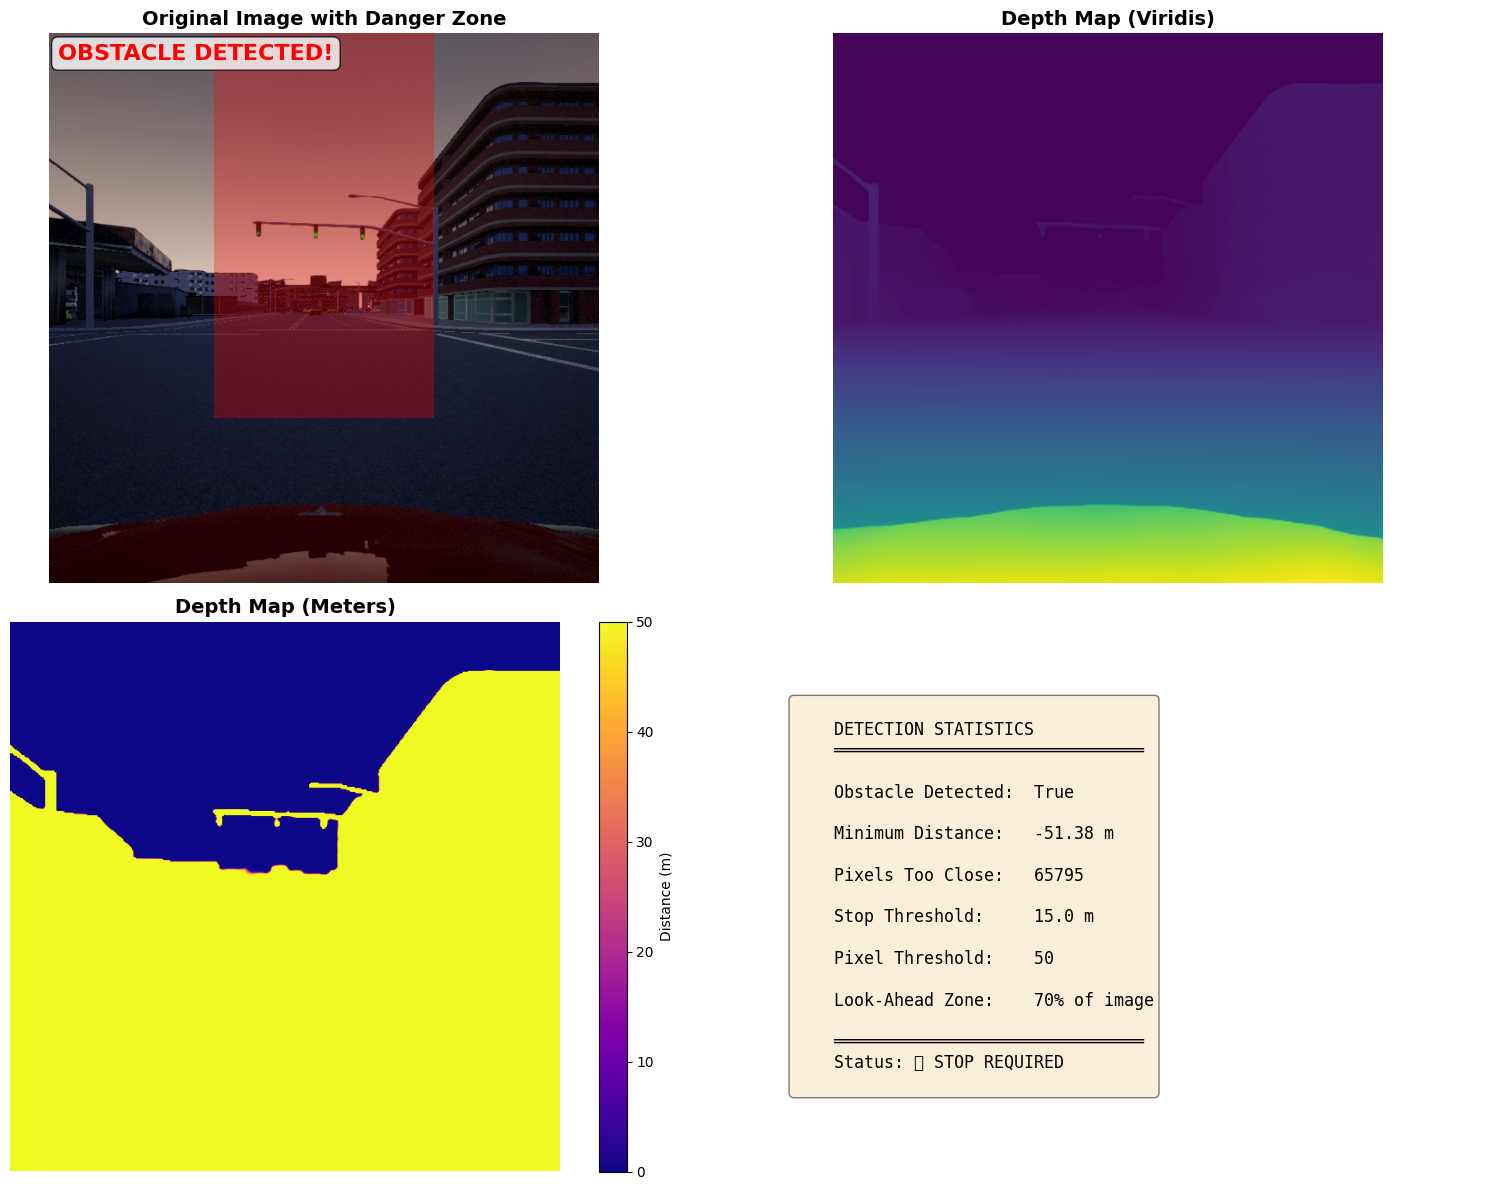

In [14]:
# Load test image
print(f"Loading image from: {INPUT_IMAGE_PATH}")

# Check if image exists, if not create a sample
if not os.path.exists(INPUT_IMAGE_PATH):
    print("⚠️ Test image not found. Please provide an image or use a video instead.")
    print("You can:")
    print("1. Place an image at:", INPUT_IMAGE_PATH)
    print("2. Change INPUT_IMAGE_PATH in the configuration cell")
    print("3. Skip to the video processing section")
else:
    # Load image
    img = cv2.imread(INPUT_IMAGE_PATH)
    if img is None:
        print("❌ Failed to load image")
    else:
        print(f"✓ Image loaded: {img.shape}")
        
        # Step 1: Estimate depth
        print("Estimating depth...")
        depth_map = estimate_depth(img, model, processor, device)
        print(f"✓ Depth map generated: {depth_map.shape}")
        print(f"  Depth range: {depth_map.min():.2f}m to {depth_map.max():.2f}m")
        
        # Step 2: Create danger zone (simple rectangular zone)
        h, w = img.shape[:2]
        danger_zone = create_simple_danger_zone(h, w, LOOK_AHEAD_Y_FRAC)
        print(f"✓ Danger zone created: {np.sum(danger_zone > 0)} pixels")
        
        # Step 3: Check for obstacles
        obstacle_found, min_dist, num_close = check_obstacle(
            depth_map, danger_zone, STOP_DISTANCE_M, PIXEL_COUNT_THRESHOLD
        )
        
        print("\n" + "="*50)
        print("DETECTION RESULT:")
        print(f"  Obstacle Detected: {obstacle_found}")
        print(f"  Minimum Distance: {min_dist:.2f}m")
        print(f"  Pixels Too Close: {num_close}")
        print("="*50 + "\n")
        
        # Step 4: Visualize
        fig = visualize_results(img, depth_map, danger_zone, obstacle_found, 
                               min_dist, num_close)
        
        # Save visualization
        output_path = os.path.join(OUTPUT_DIR, "detection_result.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"✓ Visualization saved to: {output_path}")
        
        plt.show()

## 6. Process Video

In [ ]:
def process_video(video_path, output_path, model, processor, device, 
                  max_frames=None, display_every=30):
    """
    Process video and add depth-based obstacle detection overlay.
    
    Args:
        video_path: Input video path
        output_path: Output video path
        model: Depth estimation model
        processor: Image processor
        device: torch device
        max_frames: Maximum frames to process (None for all)
        display_every: Display progress every N frames
    """
    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Failed to open video: {video_path}")
        return
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Video properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {total_frames}")
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    obstacle_count = 0
    
    print(f"\nProcessing video...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if max_frames and frame_count >= max_frames:
            break
        
        # Estimate depth
        depth_map = estimate_depth(frame, model, processor, device)
        
        # Create danger zone
        danger_zone = create_simple_danger_zone(height, width, LOOK_AHEAD_Y_FRAC)
        
        # Check for obstacles
        obstacle_found, min_dist, num_close = check_obstacle(
            depth_map, danger_zone, STOP_DISTANCE_M, PIXEL_COUNT_THRESHOLD
        )
        
        if obstacle_found:
            obstacle_count += 1
        
        # Create visualization overlay
        overlay = frame.copy()
        
        # Draw danger zone
        overlay[danger_zone > 0] = DANGER_ZONE_COLOR
        frame_vis = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        # Add status text
        status_text = "OBSTACLE!" if obstacle_found else "Clear"
        status_color = (0, 0, 255) if obstacle_found else (0, 255, 0)
        cv2.putText(frame_vis, status_text, (20, 50), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1.5, status_color, 3)
        
        # Add distance info
        dist_text = f"Min Dist: {min_dist:.1f}m"
        cv2.putText(frame_vis, dist_text, (20, 100), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        
        # Add frame counter
        frame_text = f"Frame: {frame_count}/{total_frames if not max_frames else max_frames}"
        cv2.putText(frame_vis, frame_text, (20, height - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Write frame
        out.write(frame_vis)
        
        frame_count += 1
        
        # Display progress
        if frame_count % display_every == 0:
            print(f"  Processed {frame_count} frames... "
                  f"(Obstacles detected: {obstacle_count})")
    
    # Cleanup
    cap.release()
    out.release()
    
    print(f"\n✓ Video processing complete!")
    print(f"  Total frames processed: {frame_count}")
    print(f"  Frames with obstacles: {obstacle_count} ({100*obstacle_count/frame_count:.1f}%)")
    print(f"  Output saved to: {output_path}")

print("Video processing function defined!")

In [ ]:
# Process video
if os.path.exists(INPUT_VIDEO_PATH):
    output_video_path = os.path.join(OUTPUT_DIR, "processed_video.mp4")
    
    # Process (set max_frames=300 to process only first 10 seconds at 30fps)
    process_video(
        INPUT_VIDEO_PATH, 
        output_video_path, 
        model, 
        processor, 
        device,
        max_frames=None,  # Set to a number to limit processing
        display_every=30
    )
else:
    print(f"⚠️ Video not found at: {INPUT_VIDEO_PATH}")
    print("Please update INPUT_VIDEO_PATH in the configuration cell.")

## 7. Batch Process Multiple Images

In [ ]:
def batch_process_images(image_dir, output_dir, model, processor, device):
    """
    Process all images in a directory.
    """
    # Get all image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    image_files = []
    
    for ext in image_extensions:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))
        image_files.extend(Path(image_dir).glob(f'*{ext.upper()}'))
    
    if len(image_files) == 0:
        print(f"No images found in {image_dir}")
        return
    
    print(f"Found {len(image_files)} images to process\n")
    
    results = []
    
    for i, img_path in enumerate(image_files, 1):
        print(f"[{i}/{len(image_files)}] Processing: {img_path.name}")
        
        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"  ❌ Failed to load")
            continue
        
        # Process
        depth_map = estimate_depth(img, model, processor, device)
        h, w = img.shape[:2]
        danger_zone = create_simple_danger_zone(h, w, LOOK_AHEAD_Y_FRAC)
        obstacle_found, min_dist, num_close = check_obstacle(
            depth_map, danger_zone, STOP_DISTANCE_M, PIXEL_COUNT_THRESHOLD
        )
        
        # Save result
        results.append({
            'filename': img_path.name,
            'obstacle': obstacle_found,
            'min_distance': min_dist,
            'pixels_close': num_close
        })
        
        # Create and save visualization
        fig = visualize_results(img, depth_map, danger_zone, obstacle_found, 
                               min_dist, num_close)
        output_path = os.path.join(output_dir, f"result_{img_path.stem}.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        print(f"  ✓ Obstacle: {obstacle_found}, Min dist: {min_dist:.2f}m")
    
    # Summary
    print(f"\n{'='*50}")
    print("BATCH PROCESSING SUMMARY")
    print(f"{'='*50}")
    print(f"Total images processed: {len(results)}")
    print(f"Images with obstacles: {sum(1 for r in results if r['obstacle'])}")
    print(f"Average min distance: {np.mean([r['min_distance'] for r in results]):.2f}m")
    print(f"Results saved to: {output_dir}")
    
    return results

# Example usage:
# results = batch_process_images("input_images", OUTPUT_DIR, model, processor, device)

## 8. Advanced Visualization: Depth Map Analysis

In [ ]:
def analyze_depth_distribution(depth_map, danger_zone_mask):
    """
    Analyze and visualize depth distribution in the danger zone.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of all depths
    axes[0].hist(depth_map.flatten(), bins=50, alpha=0.7, label='All pixels')
    if np.sum(danger_zone_mask) > 0:
        danger_depths = depth_map[danger_zone_mask > 0]
        axes[0].hist(danger_depths, bins=50, alpha=0.7, label='Danger zone', color='red')
    axes[0].axvline(STOP_DISTANCE_M, color='r', linestyle='--', linewidth=2, label='Stop threshold')
    axes[0].set_xlabel('Distance (m)')
    axes[0].set_ylabel('Pixel count')
    axes[0].set_title('Depth Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # CDF of danger zone depths
    if np.sum(danger_zone_mask) > 0:
        danger_depths = depth_map[danger_zone_mask > 0]
        sorted_depths = np.sort(danger_depths)
        cdf = np.arange(1, len(sorted_depths) + 1) / len(sorted_depths)
        axes[1].plot(sorted_depths, cdf, linewidth=2)
        axes[1].axvline(STOP_DISTANCE_M, color='r', linestyle='--', linewidth=2, label='Stop threshold')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Cumulative probability')
        axes[1].set_title('Cumulative Distribution (Danger Zone)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Example usage (uncomment if you have processed an image above):
# if 'depth_map' in locals() and 'danger_zone' in locals():
#     analyze_depth_distribution(depth_map, danger_zone)
#     plt.show()

## 9. Export Configuration and Results

In [ ]:
import json
from datetime import datetime

# Save configuration and results
config_results = {
    'timestamp': datetime.now().isoformat(),
    'configuration': {
        'model_path': MODEL_PATH,
        'stop_distance_m': STOP_DISTANCE_M,
        'look_ahead_y_frac': LOOK_AHEAD_Y_FRAC,
        'pixel_count_threshold': PIXEL_COUNT_THRESHOLD,
        'device': str(device)
    }
}

config_path = os.path.join(OUTPUT_DIR, 'detection_config.json')
with open(config_path, 'w') as f:
    json.dump(config_results, f, indent=2)

print(f"Configuration saved to: {config_path}")